# Logistic Regression Tutorial

Computer Vision Course

Juan Diego Perez Navarro  
T00067699

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## TODO

### 11. Multiclass Classification: Synthetic Dataset

- Generate a dataset with 500 samples, 2 features, and 3 classes
- Plot the data points with colors representing the class labels

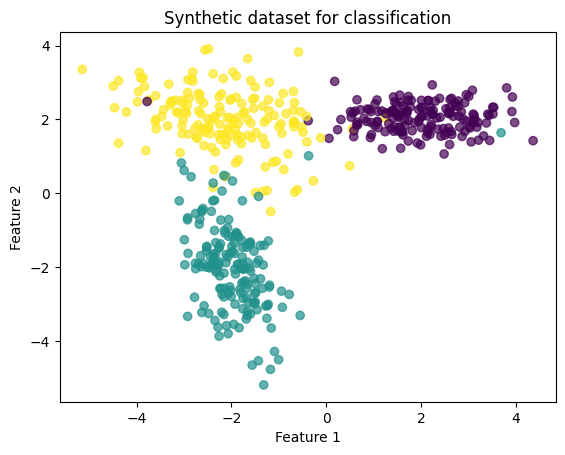

In [7]:
x, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    class_sep=2,
    random_state=40,
)

plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('Synthetic dataset for classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### 12. Training a Multinomial Logistic Regression Model

- Split the dataset into a training set and a test set (70/30)
- Create and train and a logistic regression model using `multi_class='multinomial'` and `solver='lbfgs'`

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(f'Tamaño train: {x_train.shape[0]} samples')
print(f'Tamaño test: {x_test.shape[0]} samples')

model = LogisticRegression(solver="lbfgs", multi_class="multinomial")
model.fit(x_train, y_train)

Tamaño train: 350 samples
Tamaño test: 150 samples


/home/juand/Documents/vscode/semestre7/vision_artificial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

### 13. Evaluatin the Multiclass Model

- Predict class labels for the test set
- Calculate the accuracy
- Display the confusion matrix using `ConfusionMatrixDisplay`

Accuracy: 0.96


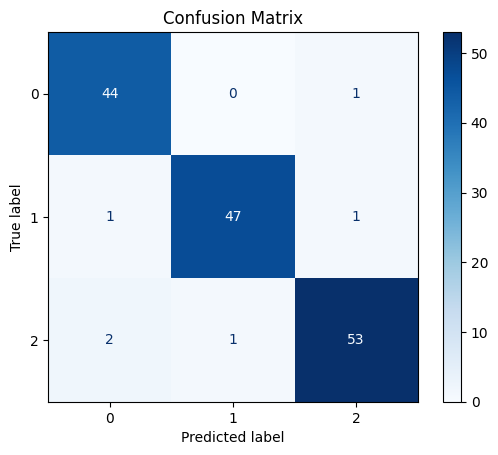

In [12]:
# Predict class labels for the test set
y_pred = model.predict(x_test)

# Compute and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### 14. Visualizing the Decision Boundaries (3 classes)

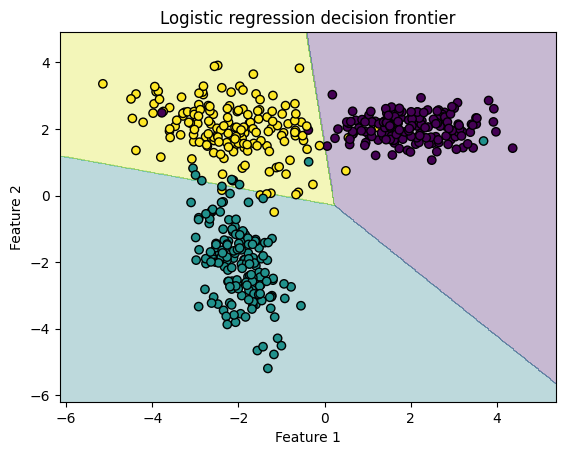

In [16]:
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title('Logistic regression decision frontier')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()